In [1]:
import torch
import torchvision
import torch.utils.data
import torchvision.transforms.v2

transforms = torchvision.transforms.v2.Compose(
    [
        torchvision.transforms.v2.Resize(224),
        torchvision.transforms.v2.Grayscale(num_output_channels=3),
        torchvision.transforms.v2.ToImage(),
        torchvision.transforms.v2.ToDtype(torch.float32, scale=True),
        torchvision.transforms.v2.Normalize((0.1307,), (0.3081,)),
    ]
)
train_ds = torchvision.datasets.MNIST("mnist", train=True, download=True, transform=transforms)
test_ds = torchvision.datasets.MNIST("mnist", train=False, download=True, transform=transforms)
classes = train_ds.class_to_idx

/usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import zigzag.nn
import zigzag.utils

dumper = zigzag.utils.UniversalDumper("mnist/vit")

model = torchvision.models.vit_b_16(
    num_classes=1000, weights=torchvision.models.ViT_B_16_Weights.DEFAULT
)
model.heads = torch.nn.Identity()

train_embeddings = dumper.execute(
    zigzag.nn.precompute_embeddings,
    "train_embeddings",
    model,
    torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=False, num_workers=3)
)
test_embeddings = dumper.execute(
    zigzag.nn.precompute_embeddings,
    "test_embeddings",
    model,
    torch.utils.data.DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=3)
)

Got the result from mnist/vit/train_embeddings.pt
Got the result from mnist/vit/test_embeddings.pt


In [3]:
train_emb_ds = torch.utils.data.TensorDataset(train_embeddings, train_ds.targets)
test_emb_ds = torch.utils.data.TensorDataset(test_embeddings, test_ds.targets)

head = torch.nn.Sequential(torch.nn.LazyLinear(len(classes)), torch.nn.Softmax(dim=1))
train_history = dumper.execute(
    zigzag.nn.train,
    "train_history",
    head,
    torch.utils.data.DataLoader(train_emb_ds, batch_size=128, shuffle=True, num_workers=3),
    torch.utils.data.DataLoader(test_emb_ds, batch_size=128, shuffle=False, num_workers=3),
)

Got the result from mnist/vit/train_history.csv


/usr/local/lib/python3.12/site-packages/torch/nn/modules/lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


In [4]:
train_img_ds = torch.utils.data.Subset(train_ds, range(1000))

hidden_states = dumper.execute(
    zigzag.nn.collect_hidden_states,
    "hidden_states",
    model,
    torch.utils.data.DataLoader(train_img_ds, batch_size=128, shuffle=False, num_workers=3)
)
num_layers = len(hidden_states)

Got the result from mnist/vit/hidden_states
Got the result from mnist/vit/hidden_states/0.pt
Got the result from mnist/vit/hidden_states/1.pt
Got the result from mnist/vit/hidden_states/2.pt
Got the result from mnist/vit/hidden_states/3.pt
Got the result from mnist/vit/hidden_states/4.pt
Got the result from mnist/vit/hidden_states/5.pt
Got the result from mnist/vit/hidden_states/6.pt
Got the result from mnist/vit/hidden_states/7.pt
Got the result from mnist/vit/hidden_states/8.pt
Got the result from mnist/vit/hidden_states/9.pt
Got the result from mnist/vit/hidden_states/10.pt
Got the result from mnist/vit/hidden_states/11.pt
Got the result from mnist/vit/hidden_states/12.pt


In [5]:
import zigzag.topology

knn_graphs = dumper.execute(
    zigzag.topology.make_knn_graphs,
    "knn_graphs",
    hidden_states,
    k_neighbors=4
)
diagrams = dumper.execute(
    zigzag.topology.compute_zigzag_barcodes,
    "diagrams",
    knn_graphs,
    dimension=3
)

Got the result from mnist/vit/knn_graphs
Got the result from mnist/vit/knn_graphs/0.npy
Got the result from mnist/vit/knn_graphs/1.npy
Got the result from mnist/vit/knn_graphs/2.npy
Got the result from mnist/vit/knn_graphs/3.npy
Got the result from mnist/vit/knn_graphs/4.npy
Got the result from mnist/vit/knn_graphs/5.npy
Got the result from mnist/vit/knn_graphs/6.npy
Got the result from mnist/vit/knn_graphs/7.npy
Got the result from mnist/vit/knn_graphs/8.npy
Got the result from mnist/vit/knn_graphs/9.npy
Got the result from mnist/vit/knn_graphs/10.npy
Got the result from mnist/vit/knn_graphs/11.npy
Got the result from mnist/vit/knn_graphs/12.npy
Got the result from mnist/vit/diagrams
Got the result from mnist/vit/diagrams/0.npy
Got the result from mnist/vit/diagrams/1.npy
Got the result from mnist/vit/diagrams/2.npy
Got the result from mnist/vit/diagrams/3.npy


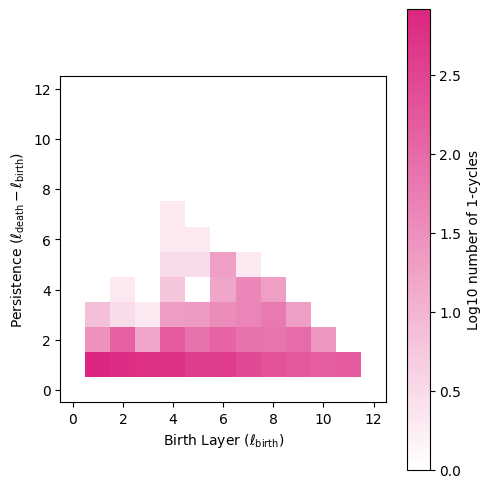

In [10]:
zigzag.topology.plot_persistence_image(diagrams[1], num_layers)
None

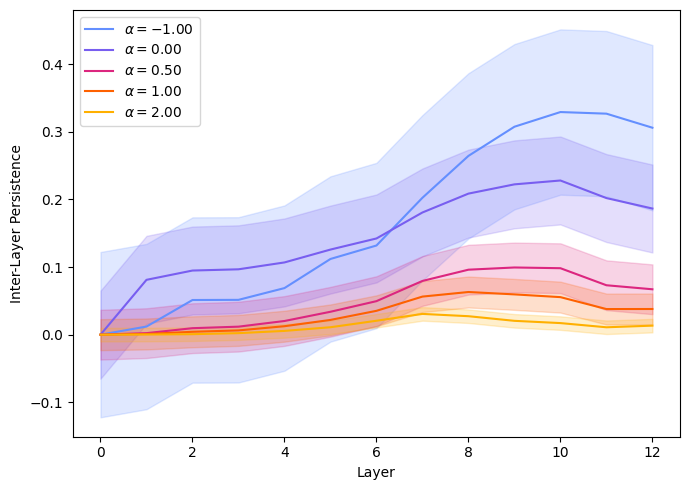

In [12]:
zigzag.topology.plot_weighted_inter_layer_persistence(diagrams[1], num_layers)

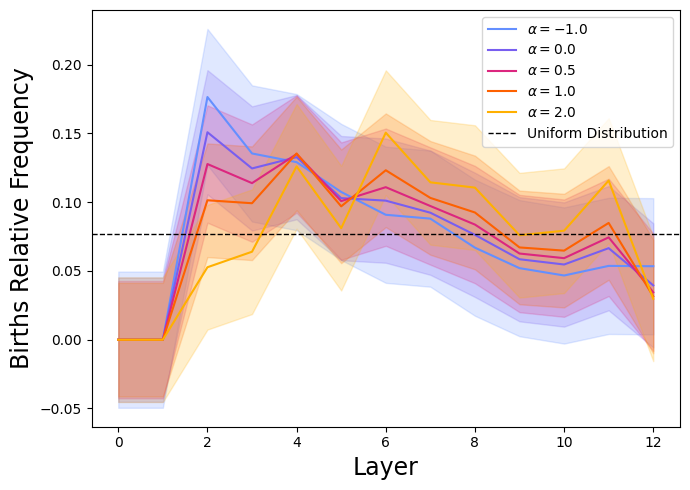

In [14]:
zigzag.topology.plot_births_relative_frequency(diagrams[1], num_layers)